In [1]:
# Import Tensorflow & Pathlib librairies
import tensorflow as tf 
import pathlib 
import pandas as pd 
import os
import io
import warnings
import spacy
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')


In [2]:
!python -m spacy download en_core_web_md -q


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


In [3]:
dataset_link = pd.read_csv("spam.csv", encoding="ISO-8859-1")


# Projet

In [4]:
dataset = dataset_link

In [5]:
dataset

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
dataset = dataset[['v1','v2']]

In [9]:
# On regarde quelques sms au hasard
print(dataset['v2'][17])
print(dataset['v2'][77])
print(dataset['v2'][117])
print(dataset['v2'][177])

Eh u remember how 2 spell his name... Yes i did. He v naughty make until i v wet.
I like you peoples very much:) but am very shy pa.
Goodo! Yes we must speak friday - egg-potato ratio for tortilla needed! 
Turns out my friends are staying for the whole show and won't be back til ~ &lt;#&gt; , so feel free to go ahead and smoke that $ &lt;#&gt;  worth


In [10]:
import en_core_web_md
nlp = en_core_web_md.load()
# Import English stop words
from spacy.lang.en.stop_words import STOP_WORDS

# Print stop words
print(STOP_WORDS)

{'along', 'yourselves', 'some', 'upon', 'during', 'yourself', 'between', 'they', 'many', 'latter', 'may', 'give', 'perhaps', "'re", 'onto', 'at', 'move', 'in', 'only', 'himself', 'he', 'whoever', 'whether', 'rather', 'two', 'which', 'her', 'against', 'among', "'ll", 'until', 'down', 'three', 'meanwhile', 'for', 'you', 'has', 'latterly', 'thus', "'m", 'much', 'below', 'was', 'made', 'see', 'ours', 'will', 'more', '‘ll', 'when', 'amongst', 'such', 'could', 'thru', 'who', 'whereby', 'using', 'whence', 'because', 'hers', '‘d', 'none', 'everything', 'were', 'through', 'least', 'there', 'eight', 'your', 'somehow', 'might', 'mostly', 'although', '’s', 'name', 'several', 'six', 'sometime', 'so', 'keep', 'this', 'besides', 'four', 'noone', 'few', 'formerly', 'last', 'own', 'become', 'regarding', 'no', 'up', 'forty', 'us', 'n’t', 'being', 'we', 'the', 'within', 'twelve', 'front', 'whither', 'thence', 'very', 'sixty', 'whom', 'still', 'via', 'almost', 'can', 'fifteen', '‘re', '’d', 'then', 're', 

In [11]:
# Garer les caractères alphanum, mettre en minuscules et lemmatizer

dataset["SMS_clean"] = dataset["v2"].apply(lambda x:''.join(ch for ch in x if ch.isalnum() or ch==" " or ch=="'"))
dataset["SMS_clean"] = dataset["SMS_clean"].apply(lambda x: x.replace(" +"," ").lower().strip())
dataset["SMS_clean"] = dataset["SMS_clean"].apply(lambda x: " ".join([token.lemma_ for token in nlp(x) if (token.lemma_ not in STOP_WORDS) and (token.text not in STOP_WORDS)]))

dataset


,v1,v2,SMS_clean
0,ham,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,u dun early hor u c
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think usf live
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,2nd time try 2 contact u u win å750 pound priz...
5568,ham,Will Ì_ b going to esplanade fr home?,ì b esplanade fr home
5569,ham,"Pity, * was in mood for that. So...any other s...",pity mood soany suggestion
5570,ham,The guy did some bitching but I acted like i'd...,guy bitch act like interested buy week free


In [12]:
dataset = dataset[dataset["SMS_clean"].notna()]
dataset.shape

(5572, 3)

In [13]:
dataset = dataset.rename(columns={'v1': 'Target', 'v2':'original_SMS'})
dataset.head()

,Target,original_SMS,SMS_clean
0,ham,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,u dun early hor u c
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think usf live


In [14]:
from collections import Counter

# Concaténer toutes les phrases en un seul texte
all_text = " ".join(dataset['SMS_clean'])

# Diviser en mots et compter les occurrences
word_counts = Counter(all_text.split())

# Nombre total de mots uniques
total_unique_words = len(word_counts)
print(f"Nombre total de mots uniques : {total_unique_words}")


Nombre total de mots uniques : 8174


In [14]:
# le nombre d emots peut être redéfini

In [16]:
import numpy as np

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=5000, oov_token="out_of_vocab") # instanciate the tokenizer / on garde 5000
tokenizer.fit_on_texts(dataset['SMS_clean'])
dataset["SMS_encoded"] = tokenizer.texts_to_sequences(dataset['SMS_clean'])


In [17]:
dataset

,Target,original_SMS,SMS_clean,SMS_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...,"[3610, 231, 446, 463, 937, 32, 48, 206, 938, 7..."
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni,"[8, 196, 464, 291, 2, 1457]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...,"[10, 301, 3, 532, 660, 30, 1458, 842, 425, 235..."
3,ham,U dun say so early hor... U c already then say...,u dun early hor u c,"[2, 125, 149, 2362, 2, 81]"
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think usf live,"[700, 20, 661, 130]"
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,2nd time try 2 contact u u win å750 pound priz...,"[266, 16, 49, 3, 92, 2, 2, 30, 1, 281, 68, 3, ..."
5568,ham,Will Ì_ b going to esplanade fr home?,ì b esplanade fr home,"[43, 110, 1539, 578, 23]"
5569,ham,"Pity, * was in mood for that. So...any other s...",pity mood soany suggestion,"[1, 932, 1, 3606]"
5570,ham,The guy did some bitching but I acted like i'd...,guy bitch act like interested buy week free,"[113, 1195, 1600, 13, 986, 88, 35, 10]"


In [18]:
dataset['Target'].value_counts() # classes déséquilibrées, voir si cela aura un immpact ? / mesures des précisions, recalls, matrices

Target
ham     4825
spam     747
Name: count, dtype: int64

In [19]:
from sklearn.utils import resample

def data_over_sampling(data, nb_boost):
    data_sample_1 = data.loc[data['Target'] == 'ham', :]
    data_sample_2 = data.loc[data['Target'] == 'spam', :]

    # Sur-échantillonnage de spam en dupliquant les données
    data_sample_2 = resample(data_sample_2, 
                             replace=True,  # Permet de rééchantillonner avec remplacement
                             n_samples=nb_boost * len(data_sample_1), 
                             random_state=42)  

    return pd.concat([data_sample_1, data_sample_2], axis=0).sample(frac=1).reset_index(drop=True)


In [20]:
data_over = data_over_sampling(dataset, 1)
data_over['Target'].value_counts()

Target
spam    4825
ham     4825
Name: count, dtype: int64

In [35]:
data_over['Target'] = data_over['Target'].replace({'ham': 0, 'spam': 1})

In [36]:
data_over.to_csv("data_over.csv")

In [109]:
data_over = pd.read_csv("data_over.csv")

In [110]:
data_over

,Unnamed: 0.1,Unnamed: 0,Target,original_SMS,SMS_clean,SMS_encoded
0,0,0,1,Ur cash-balance is currently 500 pounds - to m...,ur cashbalance currently 500 pound maximize ...,"[4, 988, 585, 320, 281, 989, 4, 990, 12, 419, ..."
1,1,1,1,"URGENT! Your Mobile No was awarded a å£2,000 B...",urgent mobile award å2000 bonus caller prize 1...,"[109, 31, 107, 260, 374, 426, 68, 4865, 266, 3..."
2,2,2,0,"Brainless Baby Doll..:-D;-), vehicle sariyag d...",brainless baby dolld vehicle sariyag drive mad...,"[1, 251, 1, 1, 1, 195, 1, 1]"
3,3,3,1,Wan2 win a Meet+Greet with Westlife 4 U or a m...,wan2 win meetgreet westlife 4 u m8 currently t...,"[3404, 30, 3405, 3406, 6, 2, 3407, 585, 1205, ..."
4,4,4,1,network operator. The service is free. For T &...,network operator service free t c visit 8048...,"[233, 507, 87, 10, 365, 81, 495, 4675]"
...,...,...,...,...,...,...
9645,9645,9645,0,K:)all the best:)congrats...,kall bestcongrat,"[4857, 4858]"
9646,9646,9646,1,83039 62735=å£450 UK Break AccommodationVouche...,83039 62735å450 uk break accommodationvoucher ...,"[1, 1, 343, 333, 1, 554, 1146, 232, 3, 46, 1, ..."
9647,9647,9647,0,Have you got Xmas radio times. If not i will g...,xma radio time,"[967, 1508, 16]"
9648,9648,9648,1,SMS AUCTION - A BRAND NEW Nokia 7250 is up 4 a...,sms auction brand new nokia 7250 4 auction t...,"[194, 462, 1189, 34, 100, 2977, 6, 462, 29, 46..."


In [ ]:
# Essai - Tf-Idf

In [111]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(data_over['SMS_encoded'])

In [112]:
X

<9650x4990 sparse matrix of type '<class 'numpy.float64'>'
	with 89569 stored elements in Compressed Sparse Row format>

In [113]:
labels = np.array(data_over['Target'])

In [114]:
labels

array([1, 1, 0, ..., 0, 1, 1], dtype=int64)

In [115]:
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.3, random_state=42)

In [116]:
X_train = X_train.toarray() 
X_test = X_test.toarray() 

In [117]:
X_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.18925504, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [118]:
train = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_batch = train.shuffle(len(train)).batch(64)
val_batch = val.shuffle(len(val)).batch(64)

In [119]:
from tensorflow import keras

first_model = keras.Sequential([
    keras.layers.Dense(10, activation='relu', input_shape=(X.shape[1],)),
    keras.layers.Dense(5, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  # Sortie binaire (0 ou 1)
])

In [120]:
first_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 10)             │        49,910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,971 (195.20 KB)

 Trainable params: 49,971 (195.20 KB)

 Non-trainable params: 0 (0.00 B)

In [121]:
first_model.compile(optimizer='adam', loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=[tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                         tf.keras.metrics.Precision(name='precision'),
                         tf.keras.metrics.Recall(name='recall')])

In [122]:
from keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint("best_model.h5", monitor="val_precision", save_best_only=True, mode="max")

history = first_model.fit(
    np.array(X_train), np.array(y_train), 
    epochs=50, 
    validation_data=val_batch, 
    verbose=1,
    callbacks=[checkpoint]  # 🛠 Sauvegarde le meilleur modèle
)





Epoch 1/50
172/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7596 - loss: 0.6303 - precision: 0.6991 - recall: 0.9180 

212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7833 - loss: 0.6066 - precision: 0.7239 - recall: 0.9272 - val_accuracy: 0.9748 - val_loss: 0.2447 - val_precision: 0.9736 - val_recall: 0.9756
Epoch 2/50
196/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9885 - loss: 0.1725 - precision: 0.9927 - recall: 0.9845

212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9886 - loss: 0.1689 - precision: 0.9927 - recall: 0.9846 - val_accuracy: 0.9879 - val_loss: 0.0723 - val_precision: 0.9895 - val_recall: 0.9861
Epoch 3/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9954 - loss: 0.0462 - precision: 0.9978 - recall: 0.9930 - val_accuracy: 0.9910 - val_loss: 0.0392 - val_precision: 0.9869 - val_recall: 0.9951
Epoch 4/50
199/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9967 - loss: 0.0242 - precision: 0.9962 - recall: 0.9973

212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9968 - loss: 0.0240 - precision: 0.9963 - recall: 0.9973 - val_accuracy: 0.9941 - val_loss: 0.0268 - val_precision: 0.9924 - val_recall: 0.9958
Epoch 5/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9977 - loss: 0.0149 - precision: 0.9972 - recall: 0.9981 - val_accuracy: 0.9948 - val_loss: 0.0221 - val_precision: 0.9917 - val_recall: 0.9979
Epoch 6/50
181/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9973 - loss: 0.0126 - precision: 0.9970 - recall: 0.9976

212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9974 - loss: 0.0123 - precision: 0.9972 - recall: 0.9977 - val_accuracy: 0.9955 - val_loss: 0.0193 - val_precision: 0.9931 - val_recall: 0.9979
Epoch 7/50
180/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9987 - loss: 0.0093 - precision: 0.9995 - recall: 0.9980

212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9987 - loss: 0.0091 - precision: 0.9994 - recall: 0.9981 - val_accuracy: 0.9962 - val_loss: 0.0164 - val_precision: 0.9944 - val_recall: 0.9979
Epoch 8/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9995 - loss: 0.0055 - precision: 0.9999 - recall: 0.9991 - val_accuracy: 0.9959 - val_loss: 0.0157 - val_precision: 0.9937 - val_recall: 0.9979
Epoch 9/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9992 - loss: 0.0061 - precision: 1.0000 - recall: 0.9985 - val_accuracy: 0.9955 - val_loss: 0.0154 - val_precision: 0.9931 - val_recall: 0.9979
Epoch 10/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9993 - loss: 0.0052 - precision: 1.0000 - recall: 0.9987 - val_accuracy: 0.9962 - val_loss: 0.0145 - val_precision: 0.9944 - val_recall: 0.9979
Epoch 11/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9996 - loss: 0.0031 - precision: 1.0000 - recall: 0.9991 - val_accuracy: 0.9955 - val_loss: 0.0150 - va

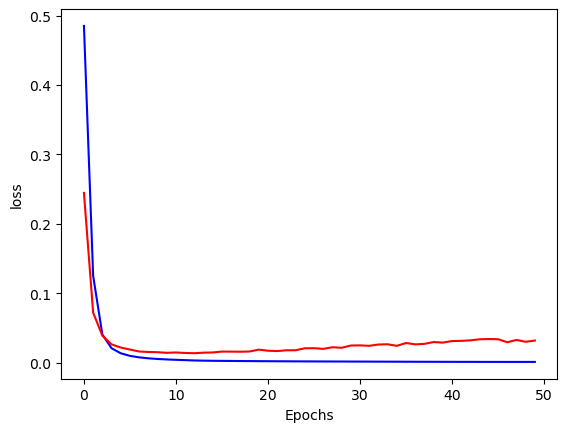

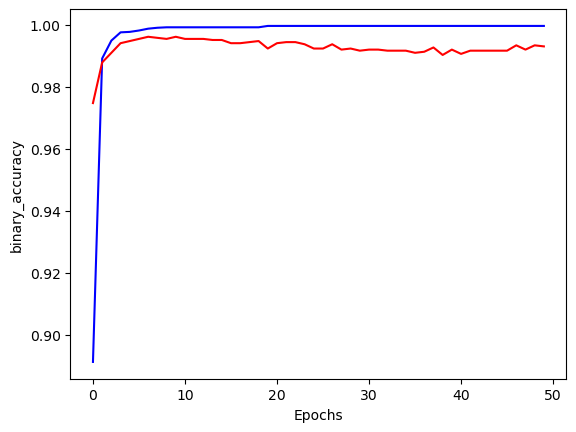

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step
Accuracy : 0.9962003454231434
Precision : 0.9944405837387075
Recall : 0.997907949790795


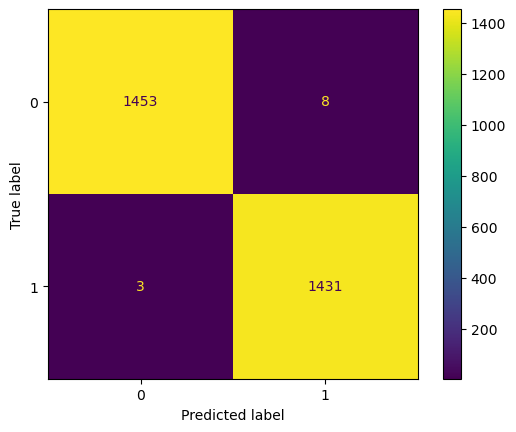

In [123]:
import matplotlib.pyplot as plt
# classes et méthodes de Scikit-Learn pour le préprocessing, le splitting, les métriques, etc...
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score

# Visualization of the training process on the loss function 
plt.plot(history.history["loss"], color="b")
plt.plot(history.history["val_loss"], color="r")
plt.ylabel("loss")
plt.xlabel("Epochs")
plt.show()

# Visualization of accuracy training 
plt.plot(history.history["accuracy"], color="b")
plt.plot(history.history["val_accuracy"], color="r")
plt.ylabel("binary_accuracy")
plt.xlabel("Epochs")
plt.show()

def display_matrix_and_scores(y_true, y_pred):
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
  print(f'Accuracy : {accuracy_score(y_true,y_pred)}')
  print(f'Precision : {precision_score(y_true,y_pred)}')
  print(f'Recall : {recall_score(y_true,y_pred)}')

from keras.models import load_model

best_model = load_model("best_model.h5")  # 🔥 Charge le meilleur modèle
y_pred = np.where(best_model.predict(X_test) > 0.5, 1, 0)

display_matrix_and_scores(y_test, y_pred)  # ✅ Résultats du meilleur modèle


In [125]:
data_over = pd.read_csv("data_over.csv")

In [126]:
data_over

,Unnamed: 0.1,Unnamed: 0,Target,original_SMS,SMS_clean,SMS_encoded
0,0,0,1,Ur cash-balance is currently 500 pounds - to m...,ur cashbalance currently 500 pound maximize ...,"[4, 988, 585, 320, 281, 989, 4, 990, 12, 419, ..."
1,1,1,1,"URGENT! Your Mobile No was awarded a å£2,000 B...",urgent mobile award å2000 bonus caller prize 1...,"[109, 31, 107, 260, 374, 426, 68, 4865, 266, 3..."
2,2,2,0,"Brainless Baby Doll..:-D;-), vehicle sariyag d...",brainless baby dolld vehicle sariyag drive mad...,"[1, 251, 1, 1, 1, 195, 1, 1]"
3,3,3,1,Wan2 win a Meet+Greet with Westlife 4 U or a m...,wan2 win meetgreet westlife 4 u m8 currently t...,"[3404, 30, 3405, 3406, 6, 2, 3407, 585, 1205, ..."
4,4,4,1,network operator. The service is free. For T &...,network operator service free t c visit 8048...,"[233, 507, 87, 10, 365, 81, 495, 4675]"
...,...,...,...,...,...,...
9645,9645,9645,0,K:)all the best:)congrats...,kall bestcongrat,"[4857, 4858]"
9646,9646,9646,1,83039 62735=å£450 UK Break AccommodationVouche...,83039 62735å450 uk break accommodationvoucher ...,"[1, 1, 343, 333, 1, 554, 1146, 232, 3, 46, 1, ..."
9647,9647,9647,0,Have you got Xmas radio times. If not i will g...,xma radio time,"[967, 1508, 16]"
9648,9648,9648,1,SMS AUCTION - A BRAND NEW Nokia 7250 is up 4 a...,sms auction brand new nokia 7250 4 auction t...,"[194, 462, 1189, 34, 100, 2977, 6, 462, 29, 46..."


In [128]:
import ast  # Module pour convertir un string en liste

data_over['SMS_encoded'] = data_over['SMS_encoded'].apply(ast.literal_eval)

sms_pad = tf.keras.preprocessing.sequence.pad_sequences(data_over['SMS_encoded'], padding="post")


In [129]:
sms_pad

array([[   4,  988,  585, ...,    0,    0,    0],
       [ 109,   31,  107, ...,    0,    0,    0],
       [   1,  251,    1, ...,    0,    0,    0],
       ...,
       [ 967, 1508,   16, ...,    0,    0,    0],
       [ 194,  462, 1189, ...,    0,    0,    0],
       [ 201,  331,   10, ...,    0,    0,    0]])

In [130]:
# Train Test Split
xtrain, xval, ytrain, yval = train_test_split(sms_pad,data_over['Target'], test_size=0.3)

In [131]:
train = tf.data.Dataset.from_tensor_slices((xtrain, ytrain))
val = tf.data.Dataset.from_tensor_slices((xval, yval))


In [132]:
train_batch = train.shuffle(len(train)).batch(64)
val_batch = val.shuffle(len(val)).batch(64)


In [133]:
 # Regardons un batch 
for review, spam in train_batch.take(1):
  print(review, spam)


tf.Tensor(
[[ 185    9 1076 ...    0    0    0]
 [   3 2838 1644 ...    0    0    0]
 [ 664  889   12 ...    0    0    0]
 ...
 [   1    7   49 ...    0    0    0]
 [ 266   16   49 ...    0    0    0]
 [ 941  154  143 ...    0    0    0]], shape=(64, 74), dtype=int32) tf.Tensor(
[0 1 1 1 0 0 1 0 0 1 1 0 0 0 1 1 1 0 0 1 0 0 1 1 0 1 1 1 1 0 0 1 0 0 1 1 0
 1 0 0 1 0 1 1 1 1 0 0 1 0 1 1 1 1 0 0 0 1 1 0 0 1 1 0], shape=(64,), dtype=int64)


In [134]:
vocab_size = tokenizer.num_words
model = tf.keras.Sequential([
                  # Couche d'Input Word Embedding           
                  tf.keras.layers.Embedding(vocab_size+1, 8, input_shape=[review.shape[1],],name="embedding"),
                  # Gobal average pooling
                  tf.keras.layers.GlobalAveragePooling1D(),

                  # Couche Dense classique
                  tf.keras.layers.Dense(16, activation='relu'),

                  # Couche de sortie avec le nombre de neurones en sortie égale au nombre de classe avec fonction softmax
                  tf.keras.layers.Dense(1, activation="sigmoid")
])


In [135]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 74, 8)          │        40,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 8)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,169 (156.91 KB)

 Trainable params: 40,169 (156.91 KB)

 Non-trainable params: 0 (0.00 B)

In [136]:
optimizer= tf.keras.optimizers.Adam()

model.compile(optimizer=optimizer,
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=[tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                         tf.keras.metrics.Precision(name='precision'),
                         tf.keras.metrics.Recall(name='recall')])


In [137]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Définir le callback pour enregistrer le meilleur modèle selon val_precision
checkpoint = ModelCheckpoint("best_model.h5", 
                             monitor="val_precision",  # Suivi de val_precision
                             save_best_only=True,      # Sauvegarde uniquement le meilleur modèle
                             mode="max",               # On veut maximiser la précision
                             verbose=1)

# Entraînement du modèle avec le callback
history = model.fit(train_batch, 
                    epochs=50, 
                    validation_data=val_batch,
                    verbose=1,
                    callbacks=[checkpoint])  # Ajout du callback ici



Epoch 1/50
100/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4956 - loss: 0.6891 - precision: 0.0014 - recall: 3.1566e-06       
Epoch 1: val_precision improved from -inf to 0.85714, saving model to best_model.h5


106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4962 - loss: 0.6887 - precision: 0.0248 - recall: 8.2425e-05 - val_accuracy: 0.4905 - val_loss: 0.6706 - val_precision: 0.8571 - val_recall: 0.0081
Epoch 2/50
 86/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5838 - loss: 0.6565 - precision: 0.9231 - recall: 0.1690       
Epoch 2: val_precision improved from 0.85714 to 0.94811, saving model to best_model.h5


106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6027 - loss: 0.6520 - precision: 0.9302 - recall: 0.2082 - val_accuracy: 0.9285 - val_loss: 0.5576 - val_precision: 0.9481 - val_recall: 0.9104
Epoch 3/50
 98/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8951 - loss: 0.5052 - precision: 0.9591 - recall: 0.8257
Epoch 3: val_precision improved from 0.94811 to 0.96057, saving model to best_model.h5


106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8952 - loss: 0.5010 - precision: 0.9594 - recall: 0.8255 - val_accuracy: 0.9309 - val_loss: 0.3508 - val_precision: 0.9606 - val_recall: 0.9024
Epoch 4/50
 95/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9210 - loss: 0.3226 - precision: 0.9619 - recall: 0.8731
Epoch 4: val_precision improved from 0.96057 to 0.97661, saving model to best_model.h5


106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9214 - loss: 0.3194 - precision: 0.9622 - recall: 0.8738 - val_accuracy: 0.9375 - val_loss: 0.2356 - val_precision: 0.9766 - val_recall: 0.8997
Epoch 5/50
 84/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9316 - loss: 0.2290 - precision: 0.9692 - recall: 0.8919
Epoch 5: val_precision improved from 0.97661 to 0.97845, saving model to best_model.h5


...

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9962 - loss: 0.0192 - precision: 0.9981 - recall: 0.9944 - val_accuracy: 0.9934 - val_loss: 0.0218 - val_precision: 0.9986 - val_recall: 0.9886
Epoch 28/50
 91/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9963 - loss: 0.0191 - precision: 0.9986 - recall: 0.9937
Epoch 28: val_precision did not improve from 0.99864
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9962 - loss: 0.0191 - precision: 0.9984 - recall: 0.9938 - val_accuracy: 0.9934 - val_loss: 0.0213 - val_precision: 0.9926 - val_recall: 0.9946
Epoch 29/50
 50/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9980 - loss: 0.0157 - precision: 0.9994 - recall: 0.9964 
Epoch 29: val_precision did not improve from 0.99864
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9974 - loss: 0.0161 - precision: 0.9992 - recall: 0.9954 - val_accuracy: 0.9938 - val_loss: 0.0207 - val_precision: 0.9933 - val_recall: 0.9946
Epoch 30/50
 93/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9974 - loss: 0.0128 - precision: 0.9985 - recall: 0.9961 - val_accuracy: 0.9945 - val_loss: 0.0189 - val_precision: 0.9986 - val_recall: 0.9906
Epoch 32/50
101/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9962 - loss: 0.0164 - precision: 0.9993 - recall: 0.9930
Epoch 32: val_precision did not improve from 0.99864
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9963 - loss: 0.0162 - precision: 0.9992 - recall: 0.9931 - val_accuracy: 0.9962 - val_loss: 0.0158 - val_precision: 0.9980 - val_recall: 0.9946
Epoch 33/50
 96/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9967 - loss: 0.0134 - precision: 0.9984 - recall: 0.9950 
Epoch 33: val_precision improved from 0.99864 to 0.99865, saving model to best_model.h5


106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9967 - loss: 0.0134 - precision: 0.9984 - recall: 0.9949 - val_accuracy: 0.9955 - val_loss: 0.0152 - val_precision: 0.9986 - val_recall: 0.9926
Epoch 34/50
 91/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9961 - loss: 0.0120 - precision: 0.9986 - recall: 0.9936
Epoch 34: val_precision did not improve from 0.99865
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9962 - loss: 0.0120 - precision: 0.9987 - recall: 0.9937 - val_accuracy: 0.9948 - val_loss: 0.0162 - val_precision: 0.9986 - val_recall: 0.9912
Epoch 35/50
 42/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9977 - loss: 0.0109 - precision: 1.0000 - recall: 0.9953 
Epoch 35: val_precision did not improve from 0.99865
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9974 - loss: 0.0113 - precision: 0.9994 - recall: 0.9953 - val_accuracy: 0.9945 - val_loss: 0.0198 - val_precision: 0.9986 - val_recall: 0.9906
Epoch 36/50
 97/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9967 - loss: 0.0128 - precision: 0.9970 - recall: 0.9963 - val_accuracy: 0.9959 - val_loss: 0.0132 - val_precision: 0.9986 - val_recall: 0.9933
Epoch 40/50
 86/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9964 - loss: 0.0119 - precision: 0.9970 - recall: 0.9955
Epoch 40: val_precision improved from 0.99865 to 0.99865, saving model to best_model.h5


106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9966 - loss: 0.0115 - precision: 0.9973 - recall: 0.9956 - val_accuracy: 0.9979 - val_loss: 0.0122 - val_precision: 0.9987 - val_recall: 0.9973
Epoch 41/50
 82/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9966 - loss: 0.0094 - precision: 0.9976 - recall: 0.9956
Epoch 41: val_precision did not improve from 0.99865
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9967 - loss: 0.0094 - precision: 0.9978 - recall: 0.9956 - val_accuracy: 0.9979 - val_loss: 0.0120 - val_precision: 0.9987 - val_recall: 0.9973
Epoch 42/50
 90/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9981 - loss: 0.0095 - precision: 0.9997 - recall: 0.9964
Epoch 42: val_precision did not improve from 0.99865
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9980 - loss: 0.0095 - precision: 0.9996 - recall: 0.9965 - val_accuracy: 0.9969 - val_loss: 0.0135 - val_precision: 0.9966 - val_recall: 0.9973
Epoch 43/50
 86/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/s

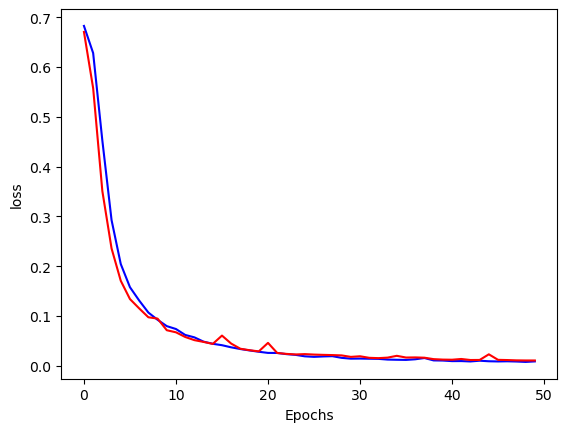

In [138]:
import matplotlib.pyplot as plt

# Visualization of the training process on the loss function 
plt.plot(history.history["loss"], color="b")
plt.plot(history.history["val_loss"], color="r")
plt.ylabel("loss")
plt.xlabel("Epochs")
plt.show()


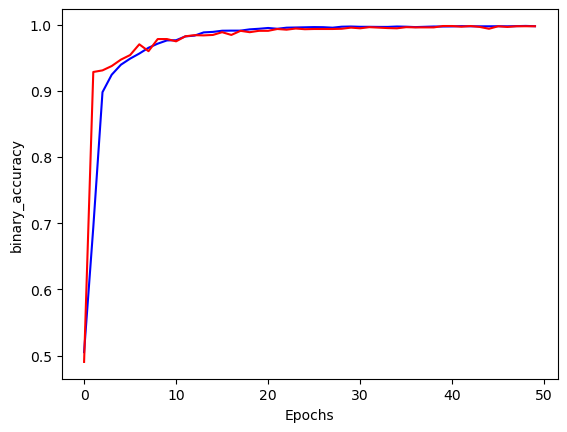

In [139]:
# Visualization of accuracy training 
plt.plot(history.history["accuracy"], color="b")
plt.plot(history.history["val_accuracy"], color="r")
plt.ylabel("binary_accuracy")
plt.xlabel("Epochs")
plt.show()

In [140]:
# classes et méthodes de Scikit-Learn pour le préprocessing, le splitting, les métriques, etc...
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score

In [141]:
def display_matrix_and_scores(y_true, y_pred):
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
  print(f'Accuracy : {accuracy_score(y_true,y_pred)}')
  print(f'Precision : {precision_score(y_true,y_pred)}')
  print(f'Recall : {recall_score(y_true,y_pred)}')

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Accuracy : 0.9975820379965458
Precision : 0.9979784366576819
Recall : 0.9973063973063973


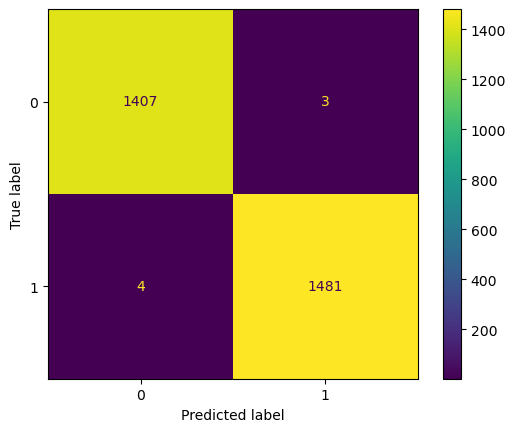

In [142]:
display_matrix_and_scores(yval, np.where(model.predict(xval) > 0.5, 1, 0))

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from transformers import AutoTokenizer

# Charger les données
data_over = pd.read_csv("data_over.csv")
import ast

# Utiliser le tokenizer de BERT
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

data_over['SMS_clean'] = data_over['SMS_clean'].fillna("")


clean_inputs = tokenizer(data_over['SMS_clean'].tolist(),  
                         padding=True, truncation=True, max_length=128, return_tensors='pt')

# Diviser les données en train et test
xtrain, xval, ytrain, yval = train_test_split(clean_inputs['input_ids'], data_over['Target'], test_size=0.3)

# Convertir les données en tensors PyTorch
train_dataset = torch.utils.data.TensorDataset(xtrain, torch.tensor(ytrain.values))
val_dataset = torch.utils.data.TensorDataset(xval, torch.tensor(yval.values))

# Créer les dataloaders
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)


In [2]:
import sympy
print(sympy.__version__)


1.13.1


In [7]:
from transformers import AutoModelForSequenceClassification, AdamW

# Charger le modèle pré-entraîné pour une tâche de classification
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# Définir l'optimiseur
optimizer = AdamW(model.parameters(), lr=2e-5)

# Vérifier si un GPU est disponible pour accélérer l'entraînement
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

c:\Users\valen\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\valen\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\valen\anaconda3\Lib\site-packages\transformers\optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [8]:
from tqdm import tqdm

# Définir la fonction d'entraînement
def train(model, train_dataloader, val_dataloader, optimizer, epochs=3):
    model.train()
    
    # Entraîner le modèle
    for epoch in range(epochs):
        total_loss = 0
        total_correct = 0
        total_samples = 0

        for batch in tqdm(train_dataloader, desc=f"Training Epoch {epoch + 1}/{epochs}"):
            input_ids, labels = [item.to(device) for item in batch]

            # Effacer les gradients
            optimizer.zero_grad()

            # Passage avant (forward pass)
            outputs = model(input_ids, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            # Backward pass
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=-1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss/total_samples}, Accuracy: {total_correct/total_samples}")
        
        # Validation après chaque époque
        evaluate(model, val_dataloader)

# Fonction pour évaluer le modèle sur les données de validation
def evaluate(model, val_dataloader):
    model.eval()
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for batch in tqdm(val_dataloader, desc="Evaluating"):
            input_ids, labels = [item.to(device) for item in batch]
            outputs = model(input_ids)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    print(f"Validation Accuracy: {total_correct/total_samples}")

# Lancer l'entraînement
train(model, train_dataloader, val_dataloader, optimizer, epochs=3)


Training Epoch 1/3:  36%|███▌      | 38/106 [09:04<16:14, 14.33s/it]


KeyboardInterrupt: 

In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',          # Dossier où enregistrer les résultats
    evaluation_strategy="epoch",     # Evaluer à la fin de chaque époque
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
)

trainer.train()


In [41]:
import re
from tensorflow.keras.preprocessing.sequence import pad_sequences


# Exemple de phrase
text = "Limited time offer: Buy one, get one free on all pizzas!"

# Nettoyage du texte
text = ''.join(ch for ch in text if ch.isalnum() or ch == " " or ch == "'")  # Supprimer ponctuation sauf apostrophes
text = re.sub(r"\s+", " ", text).lower().strip()  # Remplacer plusieurs espaces par un seul et mettre en minuscule

# Lemmatisation et suppression des stop words
text = " ".join([token.lemma_ for token in nlp(text) if token.lemma_ not in STOP_WORDS])
print(text)

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=5000, oov_token="out_of_vocab") # normalement déjà activé auparavant
tokenizer.fit_on_texts(dataset['SMS_clean'])

text_seq = tokenizer.texts_to_sequences([text])
print(text_seq)

text_pad = pad_sequences(text_seq, maxlen=sms_pad.shape[1], padding="post")
print(text_pad)

xval_tensor = tf.convert_to_tensor(text_pad)
ypred = model.predict(xval_tensor)
y_pred_classes = (ypred > 0.5).astype(int)

print(ypred)
print(y_pred_classes)


limited time offer buy free pizza
[[1, 16, 152, 88, 10, 848]]
[[  1  16 152  88  10 848   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[[0.43691584]]
[[0]]


# la précision est très importante / on veut éviter de trier par erreur un sms en spam plutot que l'inverse !

In [ ]:
# tentative de Bert

In [138]:
import torch


In [2]:
import tensorflow as tf
print(tf.__version__)




2.15.0


In [5]:
!pip install transformers

  Obtaining dependency information for tokenizers<0.19,>=0.14 from https://files.pythonhosted.org/packages/c1/02/40725eebedea8175918bd59ab80b2174d6ef3b3ef9ac8ec996e84c38d3ca/tokenizers-0.15.2-cp311-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
    --------------------------------------- 0.0/2.2 MB 330.3 kB/s eta 0:00:07
   - -------------------------------------- 0.1/2.2 MB 655.4 kB/s eta 0:00:04
   ------ --------------------------------- 0.3/2.2 MB 1.9 MB/s eta 0:00:01
   ----------- ---------------------------- 0.6/2.2 MB 2.8 MB/s eta 0:00:01
   ----------------- ---------------------- 0.9/2.2 MB 3.5 MB/s eta 0:00:01
   ------------------------ --------------- 1.3/2.2 MB 4.2 MB/s eta 0:00:01
   ------------------------------- -------- 1.7/2.2 MB 4.8 MB/s eta 0:00:01
   ----------------------------

In [6]:
import transformers
from transformers import TFAutoModel, AutoTokenizer

In [7]:
model = TFAutoModel.from_pretrained('distilbert-base-uncased')

c:\Users\valen\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


In [8]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

c:\Users\valen\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [42]:
from transformers import BertTokenizer

# Initialiser le tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_sentence(sentence):
    # Utiliser le tokenizer directement
    tokens = tokenizer(
        sentence,
        max_length=len(sentence.split()) + 20,  # Ajustez selon vos besoins
        truncation=True,
        padding='max_length',
        add_special_tokens=True,
        return_attention_mask=True,
        return_token_type_ids=False,
        return_tensors='tf'
    )
    return tokens['input_ids'], tokens['attention_mask']

# Exemple d'utilisation
input_ids, attention_mask = tokenize_sentence('Hello, I want to contact you. Cause... u win a Ipad !')
print(input_ids, attention_mask)


tf.Tensor(
[[  101  7592  1010  1045  2215  2000  3967  2017  1012  3426  1012  1012
   1012  1057  2663  1037 25249   999   102     0     0     0     0     0
      0     0     0     0     0     0     0     0]], shape=(1, 32), dtype=int32) tf.Tensor([[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]], shape=(1, 32), dtype=int32)


In [43]:
tokenize_sentence('Hello, I want to contact you. Cause... u win a Ipad !')

(<tf.Tensor: shape=(1, 32), dtype=int32, numpy=
 array([[  101,  7592,  1010,  1045,  2215,  2000,  3967,  2017,  1012,
          3426,  1012,  1012,  1012,  1057,  2663,  1037, 25249,   999,
           102,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0]])>,
 <tf.Tensor: shape=(1, 32), dtype=int32, numpy=
 array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])>)

In [ ]:
def tokenize_series(df):
  Xids = np.zeros((len(df), max(len(sentence)+20))
  Xmask = np.zeros((len(df), max(len(sentence+20))
  for i, sentence in enumerate(df):
    Xids[i, :], Xmask[i, :] =  tokenize_sentence(sentence)
  return Xids, Xmask

SyntaxError: invalid syntax. Perhaps you forgot a comma? (781991989.py, line 2)

In [46]:
X_ids_train, X_mask_train = tokenize_series(xtrain)
X_ids_val, X_mask_val = tokenize_series(xval)

NameError: name 'max_len_sentence' is not defined